In [1]:
import os
from PIL import Image
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset_path = "C:/Users/shami/Downloads/archive (6)/processed_data"

class_names = ["surprise", "sad", "neutral", "happy", "fear", "angry", "disgust"]
image_size = (48, 48)

X = []
Y = []

for label, class_name in enumerate(class_names):
    folder_path = os.path.join(dataset_path, class_name)
    
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        if file_name.lower().endswith((".jpg", ".jpeg", ".bmp", ".png")):
            image = Image.open(file_path).convert("L")
            image = image.resize(image_size)

            image_array = np.array(image)

            X.append(image_array)
            Y.append(label)

X = np.array(X)
X = np.expand_dims(X, axis = -1)
Y = np.array(Y)

num_classes = len(class_names)

X = X.astype("float32") / 255

print(X.shape)
print(Y.shape)

(49779, 48, 48, 1)
(49779,)


In [3]:
X_train, X_val_test, Y_train, Y_val_test = train_test_split(
    X,
    Y,
    test_size = 0.3,
    random_state = 42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_val_test,
    Y_val_test,
    test_size = 0.3,
    random_state = 42
)
print(X_train.shape)
print(Y_train.shape)
print(X_val.shape)
print(Y_val.shape)
print(X_test.shape)
print(Y_test.shape)

(34845, 48, 48, 1)
(34845,)
(10453, 48, 48, 1)
(10453,)
(4481, 48, 48, 1)
(4481,)


In [4]:
# dataset_path = "C:/Users/shami/Downloads/archive (5)/images/validation"

# class_names = ["surprise", "sad", "neutral", "happy", "fear", "angry"]
# image_size = (48, 48)

# X = []
# Y = []

# for label, class_name in enumerate(class_names):
#     folder_path = os.path.join(dataset_path, class_name)
    
#     for file_name in os.listdir(folder_path):
#         file_path = os.path.join(folder_path, file_name)

#         if file_name.lower().endswith((".jpg", ".jpeg", ".bmp", ".png")):
#             image = Image.open(file_path).convert("L")
#             image = image.resize(image_size)

#             image_array = np.array(image)

#             X.append(image_array)
#             Y.append(label)

# X_test = np.array(X)
# X_test = np.expand_dims(X_test, axis = -1)
# Y_test = np.array(Y)

# num_classes = len(class_names)

# X_test = X_test.astype("float32") / 255

# print(X_test.shape)
# print(Y_test.shape)

In [5]:
class_counts = np.bincount(Y_train)
num_classes = len(class_counts)
total_samples = len(Y_train)

class_weights = {}

for i, count in enumerate(class_counts):
    class_weights[i] = total_samples / (num_classes * count)

print(class_counts)
print(class_weights)

[4106 4584 5723 7994 4150 4170 4118]
{0: np.float64(1.2123373460441167), 1: np.float64(1.0859199700822737), 2: np.float64(0.8697985572002696), 3: np.float64(0.6226991672325672), 4: np.float64(1.1994836488812393), 5: np.float64(1.1937307297019528), 6: np.float64(1.2088045514466108)}


In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

In [7]:
regularizer = tf.keras.regularizers.l2(0.0005)

In [8]:
def convolutional_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=input_shape),
        data_augmentation,

        tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.35),

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(7, activation="softmax")
    ])
    return model

In [9]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience = 6,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor = "val_loss",
        factor = 0.5,
        patience = 3,
        min_lr = 1e-6
    )
]

In [10]:
conv_model = convolutional_model((48, 48, 1))
conv_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)
conv_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,639 (1.17 MB)

 Trainable params: 304,743 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, Y_train))
    .shuffle(buffer_size=len(X_train))
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

validation_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, Y_val))
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, Y_test))
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

history = conv_model.fit(train_dataset, epochs = 40, validation_data = validation_dataset, callbacks = callbacks, class_weight=class_weights)

Epoch 1/40


c:\Users\shami\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


545/545 ━━━━━━━━━━━━━━━━━━━━ 217s 383ms/step - accuracy: 0.2213 - loss: 2.1543 - val_accuracy: 0.2979 - val_loss: 2.1113 - learning_rate: 5.0000e-04
Epoch 2/40
545/545 ━━━━━━━━━━━━━━━━━━━━ 213s 390ms/step - accuracy: 0.3603 - loss: 1.8916 - val_accuracy: 0.4361 - val_loss: 1.6765 - learning_rate: 5.0000e-04
Epoch 3/40
545/545 ━━━━━━━━━━━━━━━━━━━━ 228s 419ms/step - accuracy: 0.4577 - loss: 1.6771 - val_accuracy: 0.4025 - val_loss: 1.8720 - learning_rate: 5.0000e-04
Epoch 4/40
545/545 ━━━━━━━━━━━━━━━━━━━━ 248s 393ms/step - accuracy: 0.4990 - loss: 1.5642 - val_accuracy: 0.5350 - val_loss: 1.4179 - learning_rate: 5.0000e-04
Epoch 5/40
545/545 ━━━━━━━━━━━━━━━━━━━━ 211s 387ms/step - accuracy: 0.5241 - loss: 1.4945 - val_accuracy: 0.3176 - val_loss: 2.4952 - learning_rate: 5.0000e-04
Epoch 6/40
545/545 ━━━━━━━━━━━━━━━━━━━━ 221s 405ms/step - accuracy: 0.5442 - loss: 1.4361 - val_accuracy: 0.4415 - val_loss: 1.7626 - learning_rate: 5.0000e-04
Epoch 7/40
545/545 ━━━━━━━━━━━━━━━━━━━━ 234s 429ms/

In [12]:
history.history

{'accuracy': [0.22129429876804352,
  0.3603099584579468,
  0.4576840400695801,
  0.499009907245636,
  0.5241498351097107,
  0.5442100763320923,
  0.5565217137336731,
  0.5791648626327515,
  0.5907590985298157,
  0.5932271480560303,
  0.6007461547851562,
  0.6057109832763672,
  0.6110202074050903,
  0.6171330213546753,
  0.6240206360816956,
  0.6301047205924988,
  0.6348400115966797,
  0.6379107236862183,
  0.6447696685791016,
  0.6437652707099915,
  0.6469794511795044,
  0.6479839086532593,
  0.6517434120178223,
  0.652374804019928,
  0.6542115211486816,
  0.6520017385482788,
  0.6559908390045166,
  0.6571961641311646,
  0.6575692296028137,
  0.6611852645874023],
 'loss': [2.1543169021606445,
  1.8916317224502563,
  1.67710280418396,
  1.5642104148864746,
  1.4944777488708496,
  1.4360803365707397,
  1.4017233848571777,
  1.3326398134231567,
  1.3021605014801025,
  1.2853156328201294,
  1.262804627418518,
  1.25003182888031,
  1.2324333190917969,
  1.2189961671829224,
  1.1918680667877

In [13]:
preds = conv_model.predict(validation_dataset).argmax(axis = 1)
print(classification_report(Y_val, preds, target_names=class_names))

164/164 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step
              precision    recall  f1-score   support

    surprise       0.63      0.84      0.72      1246
         sad       0.48      0.54      0.51      1357
     neutral       0.64      0.50      0.56      1746
       happy       0.91      0.79      0.84      2398
        fear       0.46      0.36      0.41      1232
       angry       0.57      0.51      0.54      1212
     disgust       0.62      0.88      0.73      1262

    accuracy                           0.64     10453
   macro avg       0.62      0.63      0.61     10453
weighted avg       0.65      0.64      0.64     10453



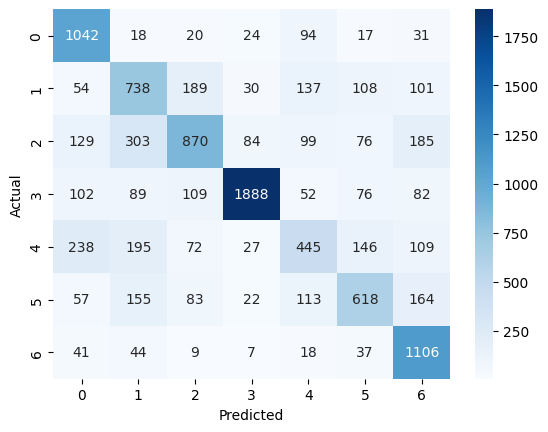

In [14]:
cm = confusion_matrix(Y_val, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [15]:
test_preds = conv_model.predict(test_dataset).argmax(axis = 1)
print(classification_report(Y_test, test_preds, target_names=class_names))

71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step
              precision    recall  f1-score   support

    surprise       0.65      0.84      0.73       568
         sad       0.49      0.55      0.52       594
     neutral       0.66      0.54      0.59       697
       happy       0.90      0.80      0.85      1006
        fear       0.48      0.36      0.41       538
       angry       0.57      0.50      0.53       538
     disgust       0.63      0.85      0.72       540

    accuracy                           0.65      4481
   macro avg       0.62      0.63      0.62      4481
weighted avg       0.65      0.65      0.64      4481



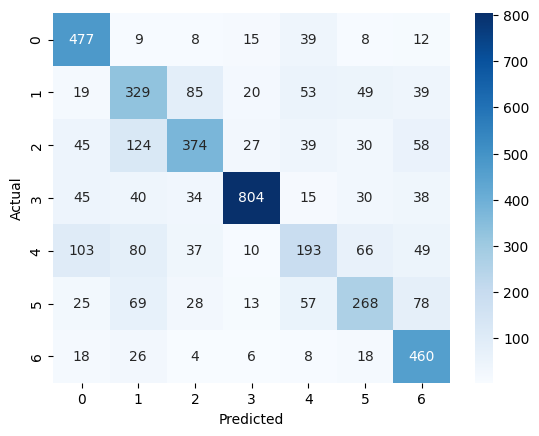

In [16]:
cm_test = confusion_matrix(Y_test, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [18]:
import pickle
with open('cnn_model.pkl', 'wb') as f:
    pickle.dump(conv_model, f)